In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
DATA = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model\weekly_curve_test.csv'
df = pd.read_csv(DATA)

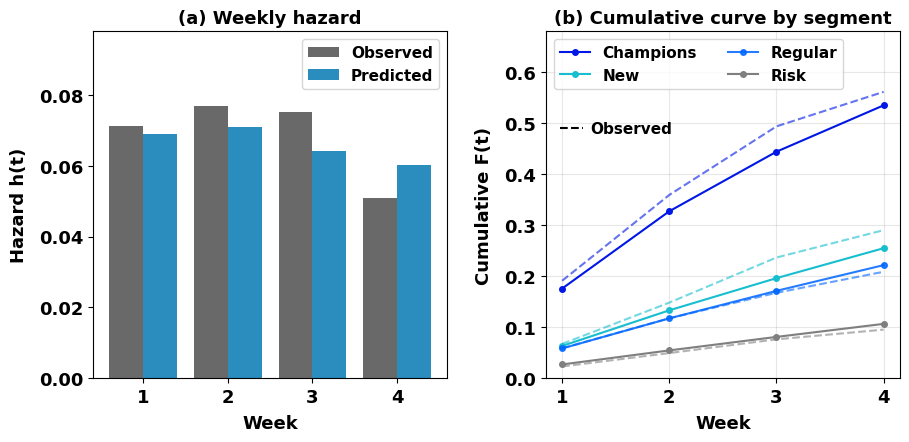

In [5]:
N = 4
weeks = np.arange(1, N+1)

ORDER  = ['Champions', 'New', 'Regular', 'Risk']
colors = {'Champions': "#0017e6", 'Regular': "#0066ffda",
          'New': 'tab:cyan', 'Risk': 'tab:gray'}

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))

# ── (a) 주차별 hazard: 관측 vs 예측 (절단본 기준) ──
alive = (df['event'] == 0) | (df['week'] <= df['week_of_repurchase'])
tr = df[alive].copy()
tr['y'] = ((tr['event'] == 1) & (tr['week'] == tr['week_of_repurchase'])).astype(int)
obs_h  = tr.groupby('week')['y'].mean().reindex(weeks).values
pred_h = tr.groupby('week')['h'].mean().reindex(weeks).values

ax[0].bar(weeks - 0.2, obs_h,  0.4, label='Observed', color='dimgray')
ax[0].bar(weeks + 0.2, pred_h, 0.4, label='Predicted', color='#2b8cbe')
ax[0].set_title('(a) Weekly hazard')
ax[0].set_xlabel('Week')
ax[0].set_ylabel('Hazard h(t)')
ax[0].set_xticks(weeks)
ax[0].set_ylim(0, 0.098)
ax[0].legend(prop={'weight': 'bold', 'size': 11}, loc='upper right')

# ── (b) 세그먼트별 누적곡선 ──
cust_seg = (df[df['week'] == N][['Customer ID','Segment','event','week_of_repurchase']]
            .drop_duplicates())
for seg in ORDER:
    pred = df[df['Segment']==seg].groupby('week')['F'].mean().reindex(weeks).values
    gc   = cust_seg[cust_seg['Segment'] == seg]
    obs  = np.array([((gc['event']==1) & (gc['week_of_repurchase']<=t)).mean() for t in weeks])
    ax[1].plot(weeks, pred, 'o-', ms=4, color=colors[seg], label=seg)
    ax[1].plot(weeks, obs,  '--',       color=colors[seg], alpha=.6)

ax[1].legend(handles=[Line2D([], [], color="#000000", ls='--', label='Observed')],
             prop={'weight': 'bold', 'size': 11},
             loc='upper left', bbox_to_anchor=(0, 0.78), frameon=False,
             handlelength=1.5, handletextpad=0.5)
ax[1].set_title('(b) Cumulative curve by segment')
ax[1].set_xlabel('Week')
ax[1].set_ylabel('Cumulative F(t)')
ax[1].set_xticks(weeks)
ax[1].set_ylim(0, 0.68)
ax[1].grid(alpha=.3)

for a in ax:
    a.tick_params(labelsize=13)
    for lbl in a.get_xticklabels() + a.get_yticklabels():
        lbl.set_fontweight('bold')
    a.set_xlabel(a.get_xlabel(), fontsize=13, fontweight='bold', labelpad=6)
    a.set_ylabel(a.get_ylabel(), fontsize=13, fontweight='bold', labelpad=8)
    a.set_title(a.get_title(), fontsize=13, fontweight='bold')

from matplotlib.lines import Line2D

leg1 = ax[1].legend(prop={'weight': 'bold', 'size': 11}, ncol=2, loc='upper left')
ax[1].add_artist(leg1)

ax[1].legend(handles=[Line2D([], [], color='k', ls='--', label='Observed')],
             prop={'weight': 'bold', 'size': 11},
             loc='upper left', bbox_to_anchor=(0, 0.78), frameon=False,
             handlelength=1.5, handletextpad=0.5)

plt.tight_layout()
plt.subplots_adjust(left=0.099, right=0.995, top=0.945, bottom=0.12, wspace=0.28)
plt.savefig(r'C:\Users\rladp\Desktop\fig3.png', dpi=300)
plt.show()

In [ ]:
h_obs = tr.groupby(['Segment','week'])['y'].mean().unstack().reindex(ORDER)
h_prd = tr.groupby(['Segment','week'])['h'].mean().unstack().reindex(ORDER)

print('── 관측 hazard ──');  print(h_obs.round(4).to_string())
print('\n── 예측 hazard ──'); print(h_prd.round(4).to_string())
print('\n── 차이 (예측 − 관측) ──'); print((h_prd - h_obs).round(4).to_string())
print('\n평균절대오차(MAE):', (h_prd - h_obs).abs().mean(axis=1).round(4).to_dict())

── 관측 hazard ──
week            1       2       3       4
Segment                                  
Champions  0.1907  0.2081  0.2100  0.1338
New        0.0669  0.0868  0.1039  0.0703
Regular    0.0582  0.0625  0.0567  0.0496
Risk       0.0225  0.0270  0.0283  0.0206

── 예측 hazard ──
week            1       2       3       4
Segment                                  
Champions  0.1754  0.1828  0.1694  0.1573
New        0.0628  0.0738  0.0712  0.0719
Regular    0.0579  0.0626  0.0605  0.0608
Risk       0.0265  0.0283  0.0279  0.0277

── 차이 (예측 − 관측) ──
week            1       2       3       4
Segment                                  
Champions -0.0153 -0.0253 -0.0406  0.0234
New       -0.0041 -0.0130 -0.0327  0.0016
Regular   -0.0003  0.0001  0.0038  0.0112
Risk       0.0040  0.0013 -0.0004  0.0071

평균절대오차(MAE): {'Champions': 0.0262, 'New': 0.0128, 'Regular': 0.0039, 'Risk': 0.0032}


In [ ]:
print('관측 순위:', h_obs.mean(axis=1).rank(ascending=False).astype(int).to_dict())
print('예측 순위:', h_prd.mean(axis=1).rank(ascending=False).astype(int).to_dict())
print('\n상대오차(%):')
print(((h_prd - h_obs) / h_obs * 100).round(1).to_string())

관측 순위: {'Champions': 1, 'New': 2, 'Regular': 3, 'Risk': 4}
예측 순위: {'Champions': 1, 'New': 2, 'Regular': 3, 'Risk': 4}

상대오차(%):
week          1     2     3     4
Segment                          
Champions  -8.0 -12.2 -19.3  17.5
New        -6.1 -15.0 -31.5   2.3
Regular    -0.5   0.2   6.7  22.7
Risk       17.7   5.0  -1.3  34.4


C:\Users\rladp\AppData\Local\Temp\ipykernel_33384\582805251.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift = c.groupby('decile')['event'].mean() / base                # 십분위별 lift


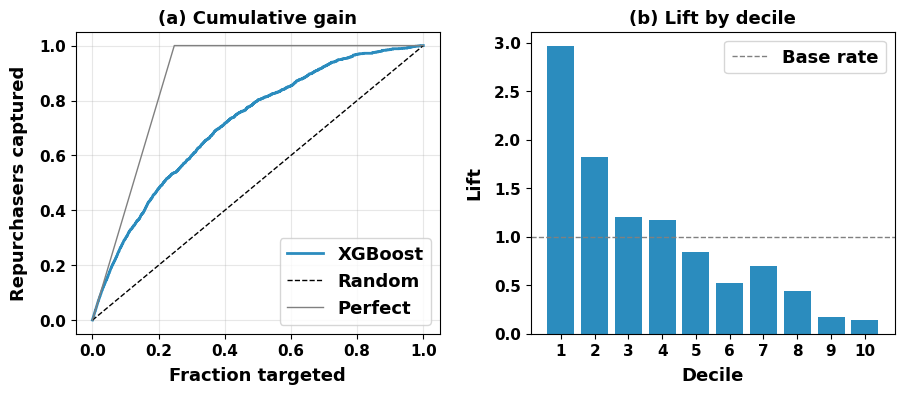

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

DATA = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model\weekly_curve_test.csv'
df = pd.read_csv(DATA)

# 고객 단위 4주 최종 (F = 4주 누적확률, event = 실제 재구매)
c = df[df['week'] == 4][['Customer ID', 'F', 'event']].copy()
c = c.sort_values('F', ascending=False).reset_index(drop=True)   # 점수 높은 순
n = len(c)
base = c['event'].mean()                                          # 전체 재구매율

# ---- (a) Cumulative gain ----
c['cum_captured'] = c['event'].cumsum() / c['event'].sum()        # 포착한 재구매자 비율
x = np.arange(1, n+1) / n                                         # 타겟한 고객 비율
# perfect: 재구매자를 먼저 다 잡는 이상선
perfect = np.minimum(np.arange(1, n+1) / c['event'].sum(), 1.0)

# ---- (b) Lift by decile ----
c['decile'] = pd.qcut(c['F'].rank(method='first', ascending=False), 10, labels=range(1, 11))
lift = c.groupby('decile')['event'].mean() / base                # 십분위별 lift

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))

# (a) Cumulative gain
ax[0].plot(x, c['cum_captured'], color='#2b8cbe', lw=2, label='XGBoost')
ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax[0].plot(x, perfect, color='gray', lw=1, label='Perfect')
ax[0].set_title('(a) Cumulative gain')
ax[0].set_xlabel('Fraction targeted')
ax[0].set_ylabel('Repurchasers captured')
ax[0].legend(fontsize=10, prop={'weight': 'bold', 'size': 13})
ax[0].grid(alpha=.3)

# (b) Lift by decile
ax[1].bar(range(1, 11), lift.values, color='#2b8cbe')
ax[1].axhline(1.0, color='gray', ls='--', lw=1, label='Random baseline')
ax[1].set_title('(b) Lift by decile')
ax[1].set_xlabel('Decile')
ax[1].set_ylabel('Lift')
ax[1].set_xticks(range(1, 11))
ax[1].legend(prop={'weight': 'bold', 'size': 13})

for a in ax:
    a.tick_params(labelsize=11)
    for lbl in a.get_xticklabels() + a.get_yticklabels():
        lbl.set_fontweight('bold')
    a.set_xlabel(a.get_xlabel(), fontsize=13, fontweight='bold', labelpad=6)
    a.set_ylabel(a.get_ylabel(), fontsize=13, fontweight='bold', labelpad=8)
    a.set_title(a.get_title(), fontsize=13, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(left=0.08, right=0.99, top=0.93, bottom=0.135, wspace=0.25)
plt.savefig(r'C:\Users\rladp\Desktop\fig4.png', dpi=300)
plt.show()

In [7]:
# ── 본문 서술값 검증 ──
tot_event = c['event'].sum()
n = len(c)

for k in [1, 2, 3, 4]:
    cum_cust  = dec['n_customers'].iloc[:k].sum()
    cum_event = dec['n_repurchase'].iloc[:k].sum()
    print(f'상위 {k*10:>2}%  →  고객 {cum_cust:,}명 ({cum_cust/n*100:.1f}%) | '
          f'재구매자 {cum_event:,}명 / {tot_event:,}명 = {cum_event/tot_event*100:.2f}%')

print()
for d in [1, 2, 3, 4]:
    print(f'{d}분위 lift = {dec["lift"].loc[d]:.4f}  →  {dec["lift"].loc[d]:.2f}배')

상위 10%  →  고객 562명 (10.0%) | 재구매자 412명 / 1,390명 = 29.64%
상위 20%  →  고객 1,124명 (20.0%) | 재구매자 666명 / 1,390명 = 47.91%
상위 30%  →  고객 1,686명 (30.0%) | 재구매자 833명 / 1,390명 = 59.93%
상위 40%  →  고객 2,248명 (40.0%) | 재구매자 996명 / 1,390명 = 71.65%

1분위 lift = 2.9635  →  2.96배
2분위 lift = 1.8270  →  1.83배
3분위 lift = 1.2012  →  1.20배
4분위 lift = 1.1725  →  1.17배


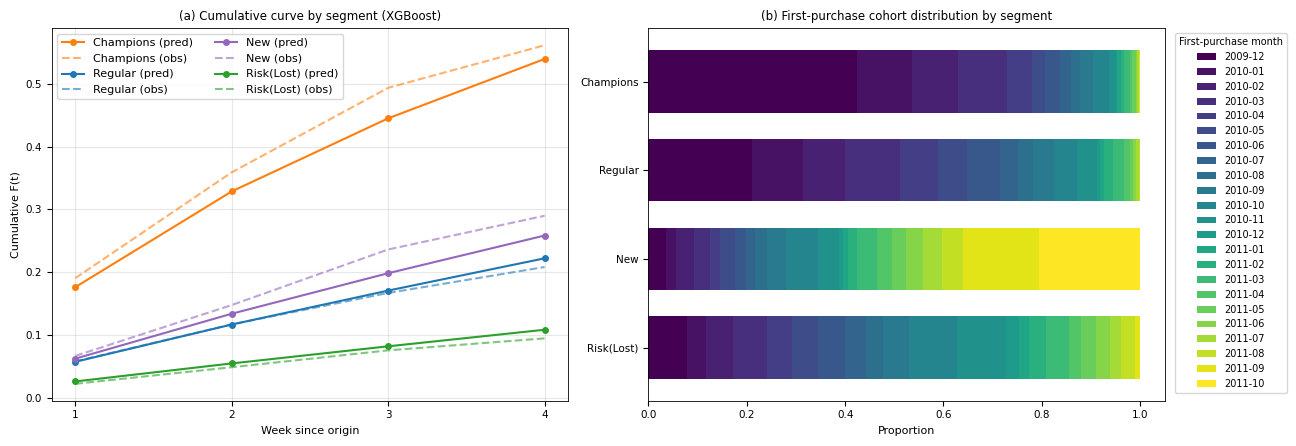

4-week cumulative F by segment:
Segment
Champions     0.5396
New           0.2585
Regular       0.2223
Risk(Lost)    0.1085
Name: F, dtype: float64

cohort match missing: 0 / 5619
세그먼트 수: 4 | 목록: ['Champions', 'New', 'Regular', 'Risk(Lost)']
배색: {'Champions': 'tab:orange', 'Regular': 'tab:blue', 'New': 'tab:purple', 'Risk(Lost)': 'tab:green'}


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

weeks = [1, 2, 3, 4]

df['Segment'] = df['Segment'].astype(str).str.strip()

# 노트북 셀 15 SEGMENT_RULES[4]가 부여하는 이름과 동일해야 함
colors = {
    'Champions':  'tab:orange',
    'Regular':    'tab:blue',
    'New':        'tab:purple',
    'Risk(Lost)': 'tab:green',
    'Risk':       'tab:green',
}

# 가치 순으로 그리면 범례 순서가 해석 순서와 맞음
SEG_ORDER = ['Champions', 'Regular', 'New', 'Risk(Lost)', 'Risk']

present = df['Segment'].unique().tolist()
seg_order = [s for s in SEG_ORDER if s in present]
seg_order += [s for s in sorted(present) if s not in seg_order]

# colors에 없는 이름은 남은 색에서 자동 배정 — 색 중복 방지
_fallback = [c for c in ['tab:red', 'tab:brown', 'tab:pink', 'tab:olive',
                         'tab:cyan', 'tab:gray']
             if c not in colors.values()]
seg_color = {}
for s in seg_order:
    seg_color[s] = colors.get(s) or _fallback.pop(0)

_missing = [s for s in seg_order if s not in colors]
if _missing:
    print('[주의] colors에 없는 세그먼트:', _missing, '— 대체 색으로 그립니다.')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# ── (a) 세그먼트별 누적곡선: 예측(실선) vs 실제(점선) ──
cust_seg = (df[df['week'] == 4]
            [['Customer ID', 'Segment', 'event', 'week_of_repurchase']]
            .drop_duplicates())

for seg in seg_order:
    c = seg_color[seg]
    g_pred = df[df['Segment'] == seg]

    # 예측 (실선)
    pred = g_pred.groupby('week')['F'].mean().reindex(weeks)
    ax[0].plot(weeks, pred.values, 'o-', ms=4, color=c,
               label=f'{seg} (pred)')

    # 실제 (점선) — 실선과 같은 색
    gc = cust_seg[cust_seg['Segment'] == seg]
    obs = [((gc['event'] == 1) & (gc['week_of_repurchase'] <= t)).mean()
           for t in weeks]
    ax[0].plot(weeks, obs, '--', color=c, alpha=0.6,
               label=f'{seg} (obs)')

ax[0].set_xticks(weeks)
ax[0].set_xlabel('Week since origin')
ax[0].set_ylabel('Cumulative F(t)')
ax[0].set_title('(a) Cumulative curve by segment (XGBoost)')
ax[0].legend(fontsize=8, ncol=2)
ax[0].grid(alpha=.3)

# ── (b) 세그먼트별 최초구매 코호트 분포 ──
cust = (df[df['week'] == 4][['Customer ID', 'Segment']]
        .merge(coh, on='Customer ID', how='left'))
ct = pd.crosstab(cust['Segment'], cust['cohort'], normalize='index')
ct = ct[sorted(ct.columns)]

# barh는 아래에서 위로 쌓이므로, 맨 위에 Champions가 오도록 역순 배치
ct = ct.reindex([s for s in seg_order if s in ct.index][::-1])

ct.plot(kind='barh', stacked=True, ax=ax[1], colormap='viridis', width=0.7)
ax[1].set_xlabel('Proportion')
ax[1].set_ylabel('')
ax[1].set_title('(b) First-purchase cohort distribution by segment')
ax[1].legend(title='First-purchase month', bbox_to_anchor=(1.01, 1),
             loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(BASE + r'\fig_segment_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# validation
print('4-week cumulative F by segment:')
print(df[df['week'] == 4].groupby('Segment')['F'].mean().round(4))
print('\ncohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))
print('세그먼트 수:', df['Segment'].nunique(), '| 목록:', sorted(df['Segment'].unique()))
print('배색:', seg_color)

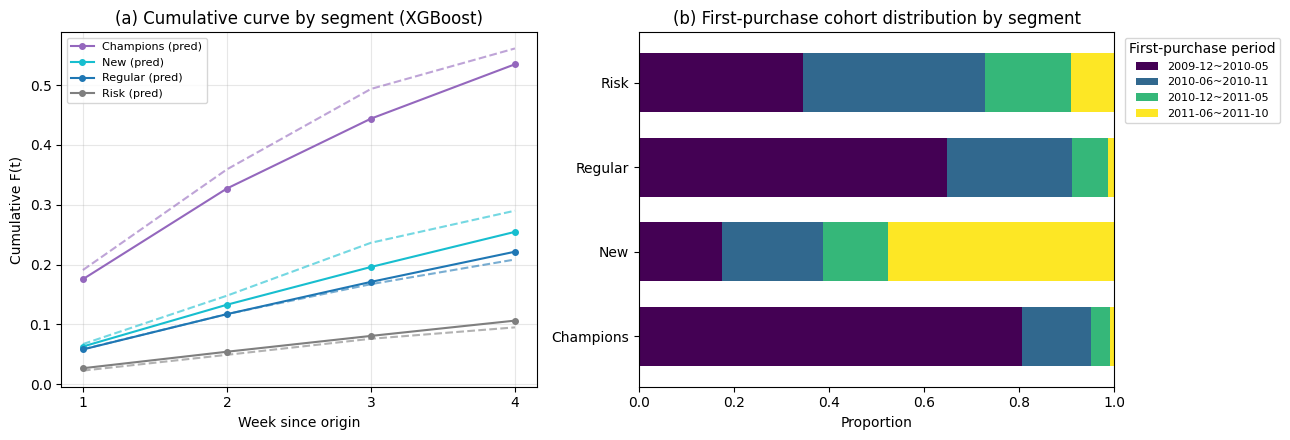

4-week cumulative F by segment:
Segment
Champions    0.5350
New          0.2546
Regular      0.2214
Risk         0.1061
Name: F, dtype: float64

cohort match missing: 0 / 5619

[구간별 개월 수]
cohort_grp
2009-12~2010-05    6
2010-06~2010-11    6
2010-12~2011-05    6
2011-06~2011-10    5

[세그먼트 × 코호트 구성비]
cohort_grp  2009-12~2010-05  2010-06~2010-11  2010-12~2011-05  2011-06~2011-10
Segment                                                                       
Champions             0.805            0.146            0.040            0.009
New                   0.175            0.212            0.137            0.476
Regular               0.648            0.263            0.074            0.014
Risk                  0.345            0.383            0.182            0.090


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

weeks = [1,2,3,4]
colors = {'Champions': 'tab:purple',
          'Regular':   'tab:blue',
          'New':       'tab:cyan',
          'Risk':      'tab:gray'}

# 코호트 묶음: 6/6/6/5개월
CUT_STARTS = ['2009-12', '2010-06', '2010-12', '2011-06']
LAST_MONTH = '2011-10'

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# ── (a) 세그먼트별 누적곡선: 실제(점선) vs 예측(실선) ──
cust_seg = df[df['week']==4][['Customer ID','Segment','event','week_of_repurchase']].drop_duplicates()

for seg, g_pred in df.groupby('Segment'):
    pred = g_pred.groupby('week')['F'].mean().reindex(weeks)
    ax[0].plot(weeks, pred.values, 'o-', ms=4, color=colors.get(seg), label=f'{seg} (pred)')
    gc = cust_seg[cust_seg['Segment']==seg]
    obs = [((gc['event']==1)&(gc['week_of_repurchase']<=t)).mean() for t in weeks]
    ax[0].plot(weeks, obs, '--', color=colors.get(seg), alpha=0.6)

ax[0].set_xticks(weeks); ax[0].set_xlabel('Week since origin'); ax[0].set_ylabel('Cumulative F(t)')
ax[0].set_title('(a) Cumulative curve by segment (XGBoost)'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# ── (b) 세그먼트별 최초구매 코호트 구성비 (6/6/6/5개월 묶음) ──
cust = df[df['week']==4][['Customer ID','Segment']].drop_duplicates('Customer ID') \
         .merge(coh, on='Customer ID', how='left')
cust['cohort_date'] = pd.to_datetime(cust['cohort'].astype(str))

starts = pd.to_datetime(CUT_STARTS)
ends   = list(starts[1:] - pd.offsets.MonthBegin(1)) + [pd.Timestamp(LAST_MONTH)]
blab   = [f'{s:%Y-%m}~{e:%Y-%m}' for s, e in zip(starts, ends)]
# 코호트 날짜가 월초이므로 경계를 월 중순에 두어 경계 걸침 방지
edges  = [starts[0] - pd.Timedelta(days=15)] + [e + pd.Timedelta(days=15) for e in ends]
cust['cohort_grp'] = pd.cut(cust['cohort_date'], bins=edges, labels=blab)

ct = pd.crosstab(cust['Segment'], cust['cohort_grp'], normalize='index')
ct = ct.reindex(columns=blab).fillna(0)
ct.plot(kind='barh', stacked=True, ax=ax[1], colormap='viridis', width=0.7)
ax[1].set_xlim(0, 1); ax[1].set_xticks(np.arange(0, 1.01, 0.2))
ax[1].set_xlabel('Proportion'); ax[1].set_ylabel('')
ax[1].set_title('(b) First-purchase cohort distribution by segment')
ax[1].legend(title='First-purchase period', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(BASE + r'\fig_segment_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# validation
print('4-week cumulative F by segment:'); print(df[df['week']==4].groupby('Segment')['F'].mean().round(4))
print('\ncohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))
print('\n[구간별 개월 수]')
print(cust.drop_duplicates('cohort').groupby('cohort_grp', observed=True)['cohort'].nunique().to_string())
print('\n[세그먼트 × 코호트 구성비]')
print(ct.round(3).to_string())

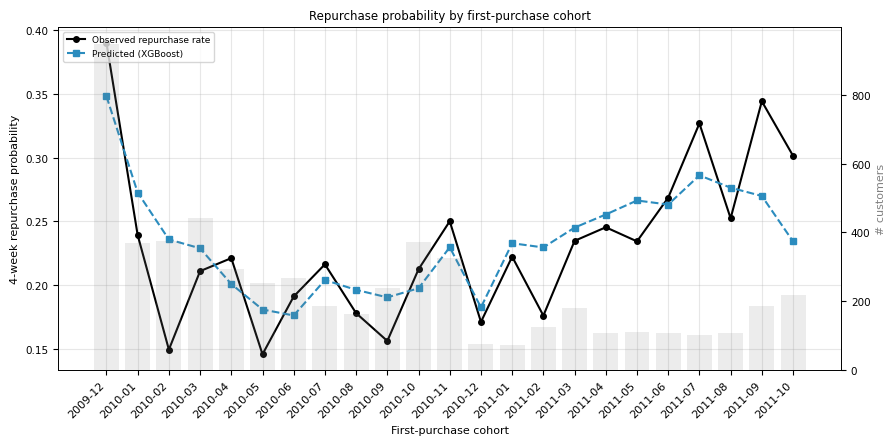

 cohort   n     실제     예측
2009-12 949 0.3899 0.3480
2010-01 368 0.2391 0.2725
2010-02 375 0.1493 0.2357
2010-03 441 0.2109 0.2288
2010-04 294 0.2211 0.2008
2010-05 254 0.1457 0.1808
2010-06 267 0.1910 0.1761
2010-07 185 0.2162 0.2039
2010-08 163 0.1779 0.1962
2010-09 237 0.1561 0.1903
2010-10 372 0.2124 0.1974
2010-11 324 0.2500 0.2296
2010-12  76 0.1711 0.1825
2011-01  72 0.2222 0.2328
2011-02 125 0.1760 0.2295
2011-03 179 0.2346 0.2450
2011-04 106 0.2453 0.2553
2011-05 111 0.2342 0.2663
2011-06 108 0.2685 0.2631
2011-07 101 0.3267 0.2860
2011-08 107 0.2523 0.2763
2011-09 186 0.3441 0.2698
2011-10 219 0.3014 0.2342

코호트 순서 vs 실제 재구매율 상관: 0.345


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# 고객 4주 최종 (F=예측 재구매확률, event=실제)
cust = (df[df['week']==4][['Customer ID','F','event']]
        .merge(coh, on='Customer ID', how='left'))

# 코호트별 집계
g = (cust.groupby('cohort')
     .agg(n=('event','size'), 실제=('event','mean'), 예측=('F','mean'))
     .reset_index().sort_values('cohort'))
g = g[g['n'] >= 20]   # 표본 너무 적은 코호트 제외 (노이즈 방지)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(g))

# 재구매확률 (좌축, 선)
ax1.plot(x, g['실제'], 'ko-', ms=4, label='Observed repurchase rate')
ax1.plot(x, g['예측'], 's--', color='#2b8cbe', ms=4, label='Predicted (XGBoost)')
ax1.set_ylabel('4-week repurchase probability')
ax1.set_xlabel('First-purchase cohort')
ax1.set_xticks(x); ax1.set_xticklabels(g['cohort'], rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper left'); ax1.grid(alpha=.3)

# 고객 수 (우축, 막대)
ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.15, color='gray')
ax2.set_ylabel('# customers', color='gray')

ax1.set_title('Repurchase probability by first-purchase cohort')
plt.tight_layout(); plt.savefig(BASE + r'\fig_cohort_repurchase.png', dpi=150); plt.show()

# 상관계수
r = np.corrcoef(np.arange(len(g)), g['실제'])[0,1]
print(g.round(4).to_string(index=False))
print(f'\n코호트 순서 vs 실제 재구매율 상관: {r:.3f}')


[Pearson correlation]
           tenure  observed  predicted
tenure      1.000    -0.345     -0.197
observed   -0.345     1.000      0.812
predicted  -0.197     0.812      1.000

[유의성 검정]
tenure vs observed: r=-0.345, p=0.1072, n=23
tenure vs predicted: r=-0.197, p=0.3685, n=23


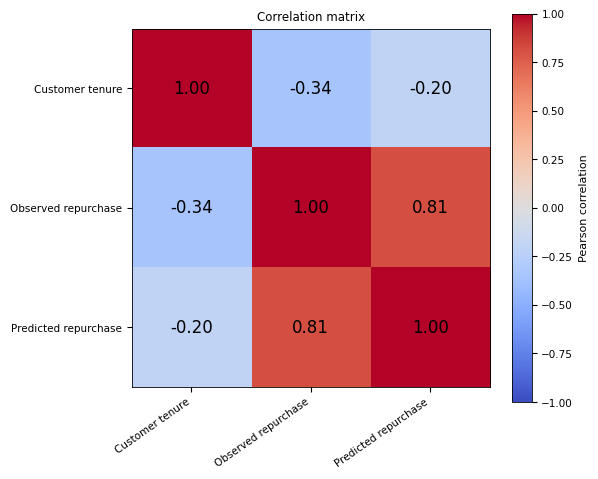

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# ------------------------------------------------------------
# 1. 고객별 4주 결과
# ------------------------------------------------------------
cust = (
    df[df['week'] == 4][['Customer ID', 'F', 'event']]
    .merge(coh, on='Customer ID', how='left')
)

# ------------------------------------------------------------
# 2. 최초구매 코호트별 집계
# ------------------------------------------------------------
g = (
    cust.groupby('cohort')
    .agg(
        n=('event', 'size'),
        observed=('event', 'mean'),
        predicted=('F', 'mean')
    )
    .reset_index()
)

g['cohort_date'] = pd.to_datetime(g['cohort'].astype(str))

# 표본 작은 코호트 제외
g = g[g['n'] >= 20].copy()

# ------------------------------------------------------------
# 3. 첫 구매 후 경과기간
#    값이 클수록 오래된 코호트
# ------------------------------------------------------------
TEST_ORIGIN = pd.Timestamp('2011-10-31')

g['tenure'] = (
    (TEST_ORIGIN.year - g['cohort_date'].dt.year) * 12
    + (TEST_ORIGIN.month - g['cohort_date'].dt.month)
)

# ------------------------------------------------------------
# 4. Pearson correlation matrix
# ------------------------------------------------------------
from scipy.stats import pearsonr

cols = ['tenure', 'observed', 'predicted']
corr = g[cols].corr(method='pearson')

print('\n[Pearson correlation]')
print(corr.round(3))

print('\n[유의성 검정]')
for c in ['observed', 'predicted']:
    r, p = pearsonr(g['tenure'], g[c])
    print(f'tenure vs {c}: r={r:.3f}, p={p:.4f}, n={len(g)}')

# ------------------------------------------------------------
# 5. Correlation heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(['Customer tenure', 'Observed repurchase', 'Predicted repurchase'])
ax.set_yticklabels(['Customer tenure', 'Observed repurchase', 'Predicted repurchase'])
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=12)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Pearson correlation')
ax.set_title('Correlation matrix')

plt.tight_layout()
plt.show()

cohort match missing: 0 / 5619


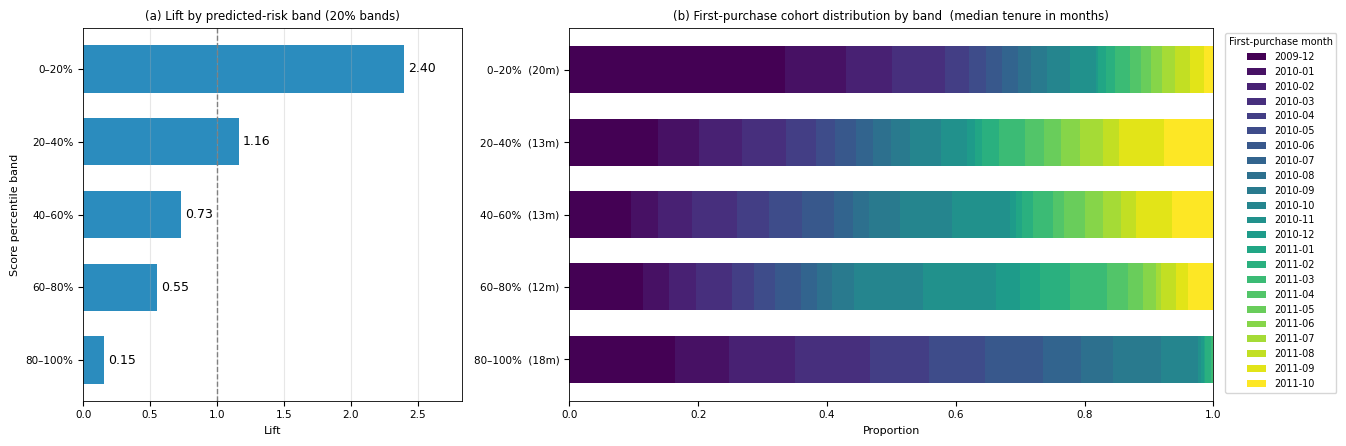

            n     obs    pred    lift  tenure_med
bin                                              
0–20%    1124  0.5934  0.5599  2.3989        20.0
20–40%   1124  0.2874  0.2821  1.1617        13.0
40–60%   1123  0.1808  0.1938  0.7307        13.0
60–80%   1124  0.1370  0.1376  0.5539        12.0
80–100%  1124  0.0383  0.0569  0.1546        18.0

Spearman(band rank, median tenure) = -0.359
(음수면 상위 구간일수록 오래된 코호트 비중이 큼)

[코호트 구간별 개월 수]
cohort_grp
2009-12~2010-05    6
2010-06~2010-11    6
2010-12~2011-05    6
2011-06~2011-10    5
미분류 고객: 0


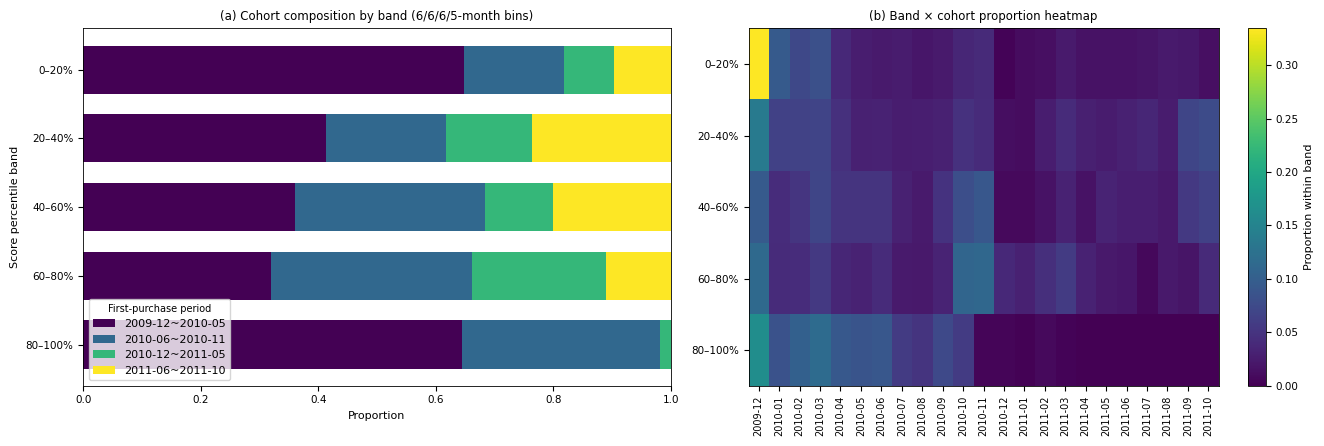


[구간 × 코호트 묶음 구성비]
cohort_grp  2009-12~2010-05  2010-06~2010-11  2010-12~2011-05  2011-06~2011-10
bin                                                                           
0–20%                 0.648            0.170            0.086            0.096
20–40%                0.413            0.205            0.146            0.237
40–60%                0.361            0.324            0.116            0.199
60–80%                0.319            0.343            0.229            0.109
80–100%               0.645            0.336            0.019            0.000


In [ ]:
# -*- coding: utf-8 -*-
"""
리프트 상위 구간(20% 단위) × 최초구매 코호트 분포
- (a) 구간별 lift (0–20% = 예측점수 상위 20%)
- (b) 구간별 최초구매 코호트 구성비 (stacked barh, 행이 (a)와 정렬됨)
- [보조] 코호트를 6/6/6/5개월 단위로 묶은 축약 버전 + 히트맵
노트북 셀에 그대로 붙여넣어 사용.
"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df  = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID']  = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

TEST_ORIGIN = pd.Timestamp('2011-10-31')
K = 5                        # 분위 수 (5=20% 단위, 10=십분위, 4=25% 단위)
CUMULATIVE = False           # True면 "상위 20% / 상위 40% / ..." 누적 구간으로 표시

step = 100 // K              # 구간 폭(%) — 라벨/눈금에 자동 반영

# ------------------------------------------------------------------
# 1. 고객 단위 4주 최종 스코어 + 코호트
# ------------------------------------------------------------------
cust = (df[df['week'] == 4][['Customer ID', 'F', 'event']]
        .drop_duplicates('Customer ID')
        .merge(coh, on='Customer ID', how='left'))
print('cohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))
cust = cust.dropna(subset=['cohort'])

# 0–20% = 상위 20%
labels = [f'{(i-1)*step}–{i*step}%' for i in range(1, K + 1)]
cust['bin'] = pd.qcut(cust['F'].rank(method='first', ascending=False),
                      K, labels=labels)

cust['cohort_date'] = pd.to_datetime(cust['cohort'].astype(str))
cust['tenure'] = ((TEST_ORIGIN.year - cust['cohort_date'].dt.year) * 12
                  + (TEST_ORIGIN.month - cust['cohort_date'].dt.month))

# ------------------------------------------------------------------
# 2. 구간별 lift / 코호트 구성비
# ------------------------------------------------------------------
base = cust['event'].mean()

if CUMULATIVE:
    # 상위 누적 구간
    order = cust.sort_values('F', ascending=False).reset_index(drop=True)
    rows, ct_rows = [], []
    for i in range(1, K + 1):
        top = order.iloc[: int(len(order) * i / K)]
        name = f'Top {i*step}%'
        rows.append(dict(grp=name, n=len(top),
                         obs=top['event'].mean(), pred=top['F'].mean(),
                         tenure_med=top['tenure'].median()))
        ct_rows.append(top['cohort'].value_counts(normalize=True).rename(name))
    agg = pd.DataFrame(rows).set_index('grp')
    ct  = pd.DataFrame(ct_rows).fillna(0)
    ylabels = agg.index.tolist()
else:
    agg = (cust.groupby('bin', observed=True)
           .agg(n=('event', 'size'), obs=('event', 'mean'),
                pred=('F', 'mean'), tenure_med=('tenure', 'median'))
           .reindex(labels))
    ct = pd.crosstab(cust['bin'], cust['cohort'], normalize='index').reindex(index=labels)
    ylabels = labels

agg['lift'] = agg['obs'] / base
ct = ct[sorted(ct.columns)]

# ------------------------------------------------------------------
# 3. 그림
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5), gridspec_kw={'width_ratios': [1, 1.7]})
y = np.arange(len(ylabels))

# (a) lift
ax[0].barh(y, agg['lift'].values, color='#2b8cbe', height=0.65)
ax[0].axvline(1.0, color='gray', ls='--', lw=1)
for i, v in enumerate(agg['lift'].values):
    ax[0].text(v + 0.03, i, f'{v:.2f}', va='center', fontsize=9)
ax[0].set_yticks(y); ax[0].set_yticklabels(ylabels)
ax[0].invert_yaxis()
ax[0].set_xlabel('Lift'); ax[0].set_xlim(0, agg['lift'].max() * 1.18)
ax[0].set_ylabel('Score percentile band')
ax[0].set_title(f'(a) Lift by predicted-risk band ({step}% bands)')
ax[0].grid(axis='x', alpha=.3)

# (b) 코호트 구성비 — y축 라벨에 코호트 중위 tenure 병기
ct.plot(kind='barh', stacked=True, ax=ax[1], colormap='viridis', width=0.65)
ax[1].invert_yaxis(); ax[1].set_xlim(0, 1)
ax[1].set_xticks(np.arange(0, 1.01, 0.2))
ax[1].set_yticks(y)
ax[1].set_yticklabels([f'{l}  ({t:.0f}m)' for l, t in zip(ylabels, agg['tenure_med'])])
ax[1].set_xlabel('Proportion'); ax[1].set_ylabel('')
ax[1].set_title('(b) First-purchase cohort distribution by band  (median tenure in months)')
ax[1].legend(title='First-purchase month', bbox_to_anchor=(1.01, 1),
             loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(BASE + rf'\fig_lift_band{step}_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 4. 검증용 수치 (본문/표 인용)
# ------------------------------------------------------------------
print(agg[['n', 'obs', 'pred', 'lift', 'tenure_med']].round(4).to_string())
if not CUMULATIVE:
    rho = (pd.Series(np.arange(1, K + 1), index=labels)
           .corr(agg['tenure_med'], method='spearman'))
    print(f'\nSpearman(band rank, median tenure) = {rho:.3f}')
    print('(음수면 상위 구간일수록 오래된 코호트 비중이 큼)')


# ==================================================================
# [보조] 코호트 6/6/6/5개월 묶음 + 히트맵
#   2009-12~2010-05 (6) / 2010-06~2010-11 (6)
#   2010-12~2011-05 (6) / 2011-06~2011-10 (5)
# ==================================================================
CUT_STARTS = ['2009-12', '2010-06', '2010-12', '2011-06']   # 각 구간 시작월
LAST_MONTH = '2011-10'                                      # 데이터 마지막 코호트월

starts = pd.to_datetime(CUT_STARTS)
ends   = list(starts[1:] - pd.offsets.MonthBegin(1)) + [pd.Timestamp(LAST_MONTH)]
blab   = [f'{s:%Y-%m}~{e:%Y-%m}' for s, e in zip(starts, ends)]
# 월초 날짜를 안전하게 담도록 경계를 월 중순에 둠
edges  = [starts[0] - pd.Timedelta(days=15)] + [e + pd.Timedelta(days=15) for e in ends]

cust['cohort_grp'] = pd.cut(cust['cohort_date'], bins=edges, labels=blab)

# 구간 정의 검증: 각 구간의 개월 수와 미분류 건수
chk = (cust.drop_duplicates('cohort')
       .groupby('cohort_grp', observed=True)['cohort'].nunique())
print('\n[코호트 구간별 개월 수]'); print(chk.to_string())
print('미분류 고객:', cust['cohort_grp'].isna().sum())

ct2 = pd.crosstab(cust['bin'], cust['cohort_grp'], normalize='index').reindex(index=labels)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))

ct2.plot(kind='barh', stacked=True, ax=ax[0], colormap='viridis', width=0.7)
ax[0].invert_yaxis(); ax[0].set_xlim(0, 1)
ax[0].set_xticks(np.arange(0, 1.01, 0.2))
ax[0].set_xlabel('Proportion'); ax[0].set_ylabel('Score percentile band')
ax[0].set_title('(a) Cohort composition by band (6/6/6/5-month bins)')
ax[0].legend(title='First-purchase period', fontsize=8, loc='lower left')

im = ax[1].imshow(ct.values, aspect='auto', cmap='viridis')
ax[1].set_xticks(range(len(ct.columns)))
ax[1].set_xticklabels(ct.columns, rotation=90, fontsize=7)
ax[1].set_yticks(range(K)); ax[1].set_yticklabels(ylabels)
ax[1].set_title('(b) Band × cohort proportion heatmap')
plt.colorbar(im, ax=ax[1], label='Proportion within band')

plt.tight_layout()
plt.savefig(BASE + rf'\fig_lift_band{step}_cohort_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[구간 × 코호트 묶음 구성비]')
print(ct2.round(3).to_string())

cohort match missing: 0 / 5619


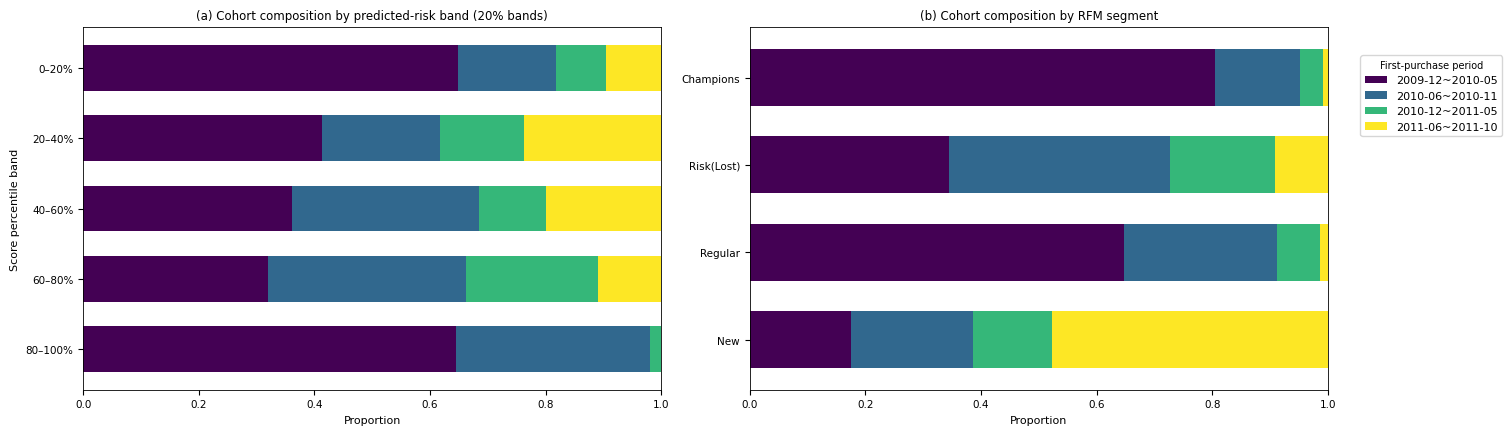


[코호트 구간별 개월 수]
cohort_grp
2009-12~2010-05    6
2010-06~2010-11    6
2010-12~2011-05    6
2011-06~2011-10    5
미분류 고객: 0

[점수 구간 × 코호트 구성비]
cohort_grp  2009-12~2010-05  2010-06~2010-11  2010-12~2011-05  2011-06~2011-10
bin                                                                           
0–20%                 0.648            0.170            0.086            0.096
20–40%                0.413            0.205            0.146            0.237
40–60%                0.361            0.324            0.116            0.199
60–80%                0.319            0.343            0.229            0.109
80–100%               0.645            0.336            0.019            0.000

[세그먼트 × 코호트 구성비]
cohort_grp  2009-12~2010-05  2010-06~2010-11  2010-12~2011-05  2011-06~2011-10
Segment                                                                       
Champions             0.805            0.146            0.040            0.009
Risk(Lost)            0.345            0.383        

In [ ]:
# -*- coding: utf-8 -*-
"""
최초구매 코호트 구성비 비교 (6/6/6/5개월 묶음)
- (a) 예측점수 구간(20% 단위)별 코호트 구성비
- (b) RFM 세그먼트별 코호트 구성비
두 패널이 동일한 코호트 묶음/색상/범례를 공유.
"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df  = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID']  = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# ------------------------------------------------------------------
# 0. 설정
# ------------------------------------------------------------------
K = 5                        # 점수 구간 수 (5=20% 단위, 4=25% 단위, 10=십분위)
CUT_STARTS = ['2009-12', '2010-06', '2010-12', '2011-06']   # 코호트 구간 시작월
LAST_MONTH = '2011-10'
SEG_ORDER  = ['Champions', 'At Risk', 'Lost', 'New / Promising']   # 위→아래

step = 100 // K
tick = step / 100

# ------------------------------------------------------------------
# 1. 고객 단위 데이터 + 코호트 묶음
# ------------------------------------------------------------------
cust = (df[df['week'] == 4][['Customer ID', 'F', 'event', 'Segment']]
        .drop_duplicates('Customer ID')
        .merge(coh, on='Customer ID', how='left'))
print('cohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))
cust = cust.dropna(subset=['cohort'])

cust['cohort_date'] = pd.to_datetime(cust['cohort'].astype(str))

starts = pd.to_datetime(CUT_STARTS)
ends   = list(starts[1:] - pd.offsets.MonthBegin(1)) + [pd.Timestamp(LAST_MONTH)]
blab   = [f'{s:%Y-%m}~{e:%Y-%m}' for s, e in zip(starts, ends)]
# 코호트 날짜가 월초이므로 경계를 월 중순에 두어 경계 걸침 방지
edges  = [starts[0] - pd.Timedelta(days=15)] + [e + pd.Timedelta(days=15) for e in ends]
cust['cohort_grp'] = pd.cut(cust['cohort_date'], bins=edges, labels=blab)

# 점수 구간 (0–20% = 상위 20%)
band_labels = [f'{(i-1)*step}–{i*step}%' for i in range(1, K + 1)]
cust['bin'] = pd.qcut(cust['F'].rank(method='first', ascending=False),
                      K, labels=band_labels)

# 세그먼트 순서 (없는 세그먼트는 제외, 정의 밖 값은 뒤에 붙임)
segs = [s for s in SEG_ORDER if s in set(cust['Segment'])]
segs += [s for s in cust['Segment'].dropna().unique() if s not in segs]

# ------------------------------------------------------------------
# 2. 구성비 계산
# ------------------------------------------------------------------
ct_band = (pd.crosstab(cust['bin'], cust['cohort_grp'], normalize='index')
           .reindex(index=band_labels, columns=blab).fillna(0))
ct_seg  = (pd.crosstab(cust['Segment'], cust['cohort_grp'], normalize='index')
           .reindex(index=segs, columns=blab).fillna(0))

# ------------------------------------------------------------------
# 3. 그림 (색상·범례 공유)
# ------------------------------------------------------------------
cmap   = plt.get_cmap('viridis')
palette = [cmap(i / max(len(blab) - 1, 1)) for i in range(len(blab))]

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))

ct_band.plot(kind='barh', stacked=True, ax=ax[0], color=palette, width=0.65, legend=False)
ax[0].invert_yaxis()
ax[0].set_xlim(0, 1); ax[0].set_xticks(np.arange(0, 1.01, tick))
ax[0].set_xlabel('Proportion'); ax[0].set_ylabel('Score percentile band')
ax[0].set_title(f'(a) Cohort composition by predicted-risk band ({step}% bands)')

ct_seg.plot(kind='barh', stacked=True, ax=ax[1], color=palette, width=0.65, legend=False)
ax[1].invert_yaxis()
ax[1].set_xlim(0, 1); ax[1].set_xticks(np.arange(0, 1.01, tick))
ax[1].set_xlabel('Proportion'); ax[1].set_ylabel('')
ax[1].set_title('(b) Cohort composition by RFM segment')

handles, _ = ax[0].get_legend_handles_labels()
fig.legend(handles, blab, title='First-purchase period',
           bbox_to_anchor=(1.005, 0.88), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(BASE + rf'\fig_cohort_band{step}_vs_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 4. 검증용 수치
# ------------------------------------------------------------------
print('\n[코호트 구간별 개월 수]')
print(cust.drop_duplicates('cohort')
      .groupby('cohort_grp', observed=True)['cohort'].nunique().to_string())
print('미분류 고객:', cust['cohort_grp'].isna().sum())

print('\n[점수 구간 × 코호트 구성비]'); print(ct_band.round(3).to_string())
print('\n[세그먼트 × 코호트 구성비]');  print(ct_seg.round(3).to_string())
print('\n[세그먼트별 고객 수]')
print(cust['Segment'].value_counts().reindex(segs).to_string())

cohort match missing: 0 / 5619


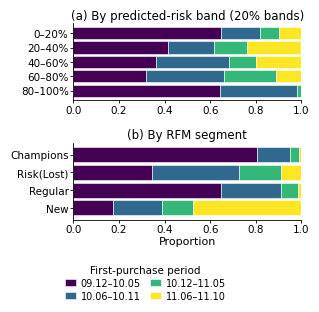


[코호트 구간별 개월 수]
cohort_grp
09.12–10.05    6
10.06–10.11    6
10.12–11.05    6
11.06–11.10    5
미분류 고객: 0

[점수 구간 × 코호트 구성비]
cohort_grp  09.12–10.05  10.06–10.11  10.12–11.05  11.06–11.10
bin                                                           
0–20%             0.648        0.170        0.086        0.096
20–40%            0.413        0.205        0.146        0.237
40–60%            0.361        0.324        0.116        0.199
60–80%            0.319        0.343        0.229        0.109
80–100%           0.645        0.336        0.019        0.000

[세그먼트 × 코호트 구성비]
cohort_grp  09.12–10.05  10.06–10.11  10.12–11.05  11.06–11.10
Segment                                                       
Champions         0.805        0.146        0.040        0.009
Risk(Lost)        0.345        0.383        0.182        0.090
Regular           0.648        0.263        0.074        0.014
New               0.175        0.212        0.137        0.476


In [ ]:
# -*- coding: utf-8 -*-
"""
논문 지면용: 최초구매 코호트 구성비 (6/6/6/5개월 묶음)
- (a) 예측점수 구간별  (b) RFM 세그먼트별
LAYOUT = 'stack' : 1단(한 칼럼) 폭에 세로 2행  ← 2단 조판 기본
LAYOUT = 'side'  : 2단 통단 figure에 가로 2열
"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df  = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID']  = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# ------------------------------------------------------------------
# 0. 설정
# ------------------------------------------------------------------
LAYOUT = 'stack'             # 'stack'(1단) | 'side'(통단)
K = 5                        # 점수 구간 수 (5=20% 단위, 4=25% 단위)
CUT_STARTS = ['2009-12', '2010-06', '2010-12', '2011-06']
LAST_MONTH = '2011-10'
SEG_ORDER  = ['Champions', 'At Risk', 'Lost', 'New / Promising']   # 위→아래
SHORT_LABEL = True           # 코호트 라벨 축약 ('09.12–10.05')

step = 100 // K
tick = step / 100

# 지면 인쇄용 폰트 (1단 폭에서 읽히는 크기)
plt.rcParams.update({
    'font.size': 8, 'axes.titlesize': 8.5, 'axes.labelsize': 8,
    'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
    'legend.fontsize': 7, 'legend.title_fontsize': 7.5,
    'axes.linewidth': 0.6, 'savefig.dpi': 300,
})

# ------------------------------------------------------------------
# 1. 고객 단위 데이터 + 코호트 묶음
# ------------------------------------------------------------------
cust = (df[df['week'] == 4][['Customer ID', 'F', 'event', 'Segment']]
        .drop_duplicates('Customer ID')
        .merge(coh, on='Customer ID', how='left'))
print('cohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))
cust = cust.dropna(subset=['cohort'])
cust['cohort_date'] = pd.to_datetime(cust['cohort'].astype(str))

starts = pd.to_datetime(CUT_STARTS)
ends   = list(starts[1:] - pd.offsets.MonthBegin(1)) + [pd.Timestamp(LAST_MONTH)]
fmt    = '%y.%m' if SHORT_LABEL else '%Y-%m'
sep    = '–' if SHORT_LABEL else '~'
blab   = [f'{s:{fmt}}{sep}{e:{fmt}}' for s, e in zip(starts, ends)]
# 코호트 날짜가 월초이므로 경계를 월 중순에 두어 경계 걸침 방지
edges  = [starts[0] - pd.Timedelta(days=15)] + [e + pd.Timedelta(days=15) for e in ends]
cust['cohort_grp'] = pd.cut(cust['cohort_date'], bins=edges, labels=blab)

band_labels = [f'{(i-1)*step}–{i*step}%' for i in range(1, K + 1)]
cust['bin'] = pd.qcut(cust['F'].rank(method='first', ascending=False),
                      K, labels=band_labels)

segs = [s for s in SEG_ORDER if s in set(cust['Segment'])]
segs += [s for s in cust['Segment'].dropna().unique() if s not in segs]

# ------------------------------------------------------------------
# 2. 구성비
# ------------------------------------------------------------------
ct_band = (pd.crosstab(cust['bin'], cust['cohort_grp'], normalize='index')
           .reindex(index=band_labels, columns=blab).fillna(0))
ct_seg  = (pd.crosstab(cust['Segment'], cust['cohort_grp'], normalize='index')
           .reindex(index=segs, columns=blab).fillna(0))

# ------------------------------------------------------------------
# 3. 그림
# ------------------------------------------------------------------
cmap    = plt.get_cmap('viridis')
palette = [cmap(i / max(len(blab) - 1, 1)) for i in range(len(blab))]

if LAYOUT == 'stack':        # 1단 폭(약 8.5cm) × 세로 2행
    fig, ax = plt.subplots(2, 1, figsize=(3.35, 3.3))
    ncol_leg = 2
    fig.subplots_adjust(left=0.285, right=0.965, top=0.93, bottom=0.335, hspace=0.55)
    leg_y = 0.215
else:                        # 통단(약 17cm) × 가로 2열
    fig, ax = plt.subplots(1, 2, figsize=(6.9, 2.2))
    ncol_leg = 4
    fig.subplots_adjust(left=0.145, right=0.985, top=0.91, bottom=0.31, wspace=0.40)
    leg_y = 0.185

BAR_W = 0.85                 # 막대 두께 (막대 사이 여백 축소)

ct_band.plot(kind='barh', stacked=True, ax=ax[0], color=palette,
             width=BAR_W, legend=False, edgecolor='white', linewidth=0.4)
ax[0].set_title(f'(a) By predicted-risk band ({step}% bands)', pad=3)

ct_seg.plot(kind='barh', stacked=True, ax=ax[1], color=palette,
            width=BAR_W, legend=False, edgecolor='white', linewidth=0.4)
ax[1].set_title('(b) By RFM segment', pad=3)

for i, a in enumerate(ax):
    a.invert_yaxis()
    a.set_xlim(0, 1); a.set_xticks(np.arange(0, 1.01, tick))
    a.set_ylabel('')
    a.tick_params(length=2, width=0.6, pad=1.5)
    for sp in ('top', 'right'):
        a.spines[sp].set_visible(False)
    # 'Proportion'은 마지막 축에만 (stack에서 중복 라벨이 여백을 먹음)
    last = (i == len(ax) - 1) if LAYOUT == 'stack' else True
    a.set_xlabel('Proportion' if last else '', labelpad=1.5)

handles, _ = ax[0].get_legend_handles_labels()
fig.legend(handles, blab, title='First-purchase period', ncol=ncol_leg,
           loc='upper center', bbox_to_anchor=(0.5, leg_y),
           frameon=False, handlelength=1.1, handletextpad=0.5,
           columnspacing=1.0, borderpad=0.1, labelspacing=0.3)

fig.savefig(BASE + rf'\fig5_cohort_{LAYOUT}.png', dpi=300)
plt.show()

# ------------------------------------------------------------------
# 4. 검증용 수치
# ------------------------------------------------------------------
print('\n[코호트 구간별 개월 수]')
print(cust.drop_duplicates('cohort')
      .groupby('cohort_grp', observed=True)['cohort'].nunique().to_string())
print('미분류 고객:', cust['cohort_grp'].isna().sum())
print('\n[점수 구간 × 코호트 구성비]'); print(ct_band.round(3).to_string())
print('\n[세그먼트 × 코호트 구성비]');  print(ct_seg.round(3).to_string())

purchase rows: 776579 | customers: 5852


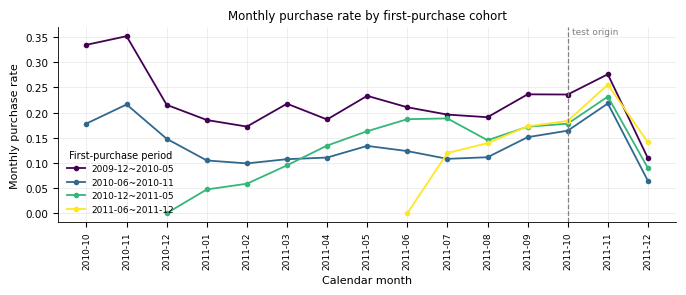


[코호트 규모]


NameError: name 'denom' is not defined

In [ ]:
# -*- coding: utf-8 -*-
"""
달력 월별 코호트 재구매율 (2010-10 이후)
- x축: 실제 달력 월,  선: 최초구매 코호트
- 값: 해당 코호트 고객 중 그 달에 구매한 비율 (실측)
- 경과기간이 아니라 달력 시간축이므로 계절성/피크가 드러남
"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0. 설정
# ------------------------------------------------------------------
RAW  = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\retail_preprocessed.csv'
SAVE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'

VIEW_START  = '2010-10'      # 그림 시작 달력 월
MIN_N       = 20             # 코호트 최소 고객 수
GROUP_COHORT = True          # True면 코호트를 구간으로 묶어 선 수를 줄임
CUT_STARTS  = ['2009-12', '2010-06', '2010-12', '2011-06']
TEST_ORIGIN = '2011-10'      # 세로 점선 표시 (테스트 원점)

plt.rcParams.update({'font.size': 8, 'axes.titlesize': 8.5, 'axes.labelsize': 8,
                     'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
                     'legend.fontsize': 6.5, 'legend.title_fontsize': 7,
                     'savefig.dpi': 300})

# ------------------------------------------------------------------
# 1. 로드 + 순수 구매 행
# ------------------------------------------------------------------
tx = pd.read_csv(RAW, usecols=['InvoiceDate', 'Customer ID', 'is_purchase'],
                 parse_dates=['InvoiceDate'], low_memory=False)
tx['Customer ID'] = tx['Customer ID'].astype(str).str.replace(r'\.0$', '', regex=True)
tx = tx[tx['is_purchase'].astype(bool)]
tx = tx[tx['Customer ID'].notna() & ~tx['Customer ID'].isin(['nan', ''])]
tx = tx.dropna(subset=['InvoiceDate'])
print('purchase rows:', len(tx), '| customers:', tx['Customer ID'].nunique())

# ------------------------------------------------------------------
# 2. 코호트 지정 (전체 기간 기준으로 먼저 확정)
# ------------------------------------------------------------------
tx['order_month'] = tx['InvoiceDate'].dt.to_period('M')
first = tx.groupby('Customer ID')['order_month'].min().rename('cohort')
tx = tx.join(first, on='Customer ID')

LAST_MONTH = tx['order_month'].max()
START = pd.Period(VIEW_START, freq='M')
months = pd.period_range(START, LAST_MONTH, freq='M')

# 코호트 묶음
if GROUP_COHORT:
    starts = pd.PeriodIndex(CUT_STARTS, freq='M')
    ends   = list(starts[1:] - 1) + [LAST_MONTH]
    blab   = [f'{s}~{e}' for s, e in zip(starts, ends)]
    lut = {}
    for s, e, lb in zip(starts, ends, blab):
        for c in pd.period_range(s, e, freq='M'):
            lut[c] = lb
    tx['grp'] = tx['cohort'].map(lut)
    key, order = 'grp', blab
else:
    tx['grp'] = tx['cohort']
    key = 'grp'
    order = sorted(tx['grp'].unique())

# ------------------------------------------------------------------
# 3. 달력 월 × 코호트 재구매율
#    분자: k>=1 인 구매만 (첫 구매월 제외 = 순수 재구매)
#    분모: 해당 월까지 이미 유입된 고객 수만
# ------------------------------------------------------------------
cust = tx.drop_duplicates('Customer ID')[['Customer ID', 'cohort', key]]

# 분자: 고객-월 단위, 첫 구매월 이후만
tx['k'] = (tx['order_month'] - tx['cohort']).apply(lambda x: x.n)
act = (tx[tx['k'] >= 1]
       .drop_duplicates(['Customer ID', 'order_month'])
       .groupby([key, 'order_month'], observed=True)['Customer ID'].size()
       .unstack(fill_value=0)
       .reindex(columns=months, fill_value=0))

# 분모: 각 달 시점에 이미 유입된 고객 수 (누적)
elig = (cust.groupby([key, 'cohort'], observed=True)['Customer ID'].size()
        .unstack(fill_value=0)
        .reindex(columns=pd.period_range(cust['cohort'].min(), LAST_MONTH, freq='M'),
                 fill_value=0)
        .cumsum(axis=1)
        .reindex(columns=months))

rate = (act.reindex(index=elig.index) / elig).reindex(index=order)
rate = rate.mask(elig.reindex(index=order) < MIN_N)   # 표본 부족 구간 제외

# ------------------------------------------------------------------
# 4. 그림
# ------------------------------------------------------------------
cmap = plt.get_cmap('viridis')
cols = [cmap(i / max(len(rate.index) - 1, 1)) for i in range(len(rate.index))]

fig, ax = plt.subplots(figsize=(6.9, 3.0))
x = np.arange(len(months))
for (g, row), col in zip(rate.iterrows(), cols):
    ax.plot(x, row.values, 'o-', ms=3, lw=1.3, color=col, label=str(g))

if TEST_ORIGIN in [str(m) for m in months]:
    ax.axvline([str(m) for m in months].index(TEST_ORIGIN), color='gray',
               ls='--', lw=0.9)
    ax.text([str(m) for m in months].index(TEST_ORIGIN) + 0.1, ax.get_ylim()[1],
            'test origin', fontsize=6.5, color='gray', va='top')

ax.set_xticks(x); ax.set_xticklabels([str(m) for m in months], rotation=90, fontsize=6.5)
ax.set_xlabel('Calendar month'); ax.set_ylabel('Monthly purchase rate')
ax.set_title('Monthly purchase rate by first-purchase cohort')
ax.grid(alpha=.3, lw=.5)
ax.legend(title='First-purchase period', fontsize=6.5, title_fontsize=7, frameon=False)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(SAVE + rf'\fig_calendar_retention_{VIEW_START}.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 5. 검증용 수치
# ------------------------------------------------------------------
print('\n[코호트 규모]'); print(denom.reindex(rate.index).to_string())
print('\n[달력 월 × 코호트 재구매율 (%)]')
print((rate * 100).round(1).to_string())